[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/17_industry_applications.ipynb)

# 📓 Notebook 17 (fast track) — Industry Applications: Churn, Fraud & Beyond

> **Module:** Industry Applications · **Estimated time:** 70–85 min · **Difficulty:** Intermediate

> 🏎️ **You're on the fast track.** This one notebook condenses a whole four-lesson module — the canonical [`05_industry_applications/`](../05_industry_applications/) folder: **NB 17** churn & CLV, **NB 18** fraud & anomaly detection, **NB 19** segmentation & recommenders, and **NB 20** demand forecasting & predictive maintenance. We work **three** of them end to end — churn, fraud, and segmentation — and point at the last (demand). Open the canonical module when you want the full depth (uplift models, RFM + k-means, the newsvendor rule, and more).

Every notebook so far taught you to *build a model*. This module is about the sentence that comes **after** the model: *"…so what do we actually **do**?"* That is the whole job of applied data science inside a business — and it is where most projects quietly fail. A model that is 92% accurate and a model that makes the company €400k are not the same achievement, and the gap between them is everything below.

> 🧭 **Mental model for this notebook — a probability is not a decision.** A classifier hands you a number like `0.73`. That number is not an action. It becomes one *only* when you attach **costs**: the price of a retention offer, the salary of a fraud analyst, the euros lost to a stockout. Watch the same three-beat rhythm carry every case below — **model → money → decision**: a probability, then a cost structure, then a rule (an expected-value threshold, a review-queue capacity, a service level). The model is a *third* of the work.

> ✅ **Prerequisites.** Fast-track **NB 8** (scikit-learn: split / fit / predict / probabilities) and **NB 16** (evaluation & feature engineering — leakage, cost-aware metrics). Everything here is generated inline and runs 100% offline.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Explain the module's shared throughline — **model → money → decision** — and why a probability only becomes an action through costs.
2. Compute a simple **customer lifetime value (CLV)** for a subscription business and attach it to each customer.
3. Derive the **expected-value offer threshold** from offer cost, save rate, and CLV — and see why a global `0.5` cutoff is wrong for *every* customer.
4. Simulate a **budget-constrained retention campaign** and compare targeting strategies by realized profit.
5. Recognise the **accuracy trap** on imbalanced data and evaluate a rare-event detector with **precision@k** and a capacity-sized **review queue**.
6. Convert model alerts into **expected euros prevented**, weighing analyst review cost against fraud loss.
7. Place **segmentation** and **demand/maintenance** in the same model → money → decision frame.

## 1. The shared pattern: model → money → decision

Four very different business problems — who will cancel, which payment is fraud, which customers cluster together, how much stock to order — turn out to be the *same* pipeline wearing different clothes:

| Beat | Churn (Case A) | Fraud (Case B) | Segmentation (Case C) | Demand (NB 20) |
|---|---|---|---|---|
| **Model** | P(cancel) | P(fraud) / anomaly score | which cluster | forecast demand |
| **Money** | offer cost, save rate, CLV | review cost, fraud loss | reachable value per segment | holding vs stockout cost |
| **Decision** | who gets a retention offer | how big a review queue | which campaign per segment | how much to order |

The **model** column is the part every course teaches. The **money** column is what turns a notebook into a business result, and the **decision** column is the only thing the company actually pays for. Keep your eye on the right two columns — they are what separate this module from *"we trained a classifier."*

We now walk **Case A (churn)** and **Case B (fraud)** all the way across that table, then sketch the other two rows.

## Setup

One import block for the whole notebook, and a fixed `RANDOM_STATE` so every run is identical.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, precision_recall_curve,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)
BLUE, RED, GREEN, ORANGE = "#4C72B0", "#C44E52", "#55A868", "#DD8452"

print("Ready ✅")

Ready ✅


# 💸 Case A — Churn & CLV targeting

> Canonical depth: [`05_industry_applications/17_churn_clv_retention.ipynb`](../05_industry_applications/17_churn_clv_retention.ipynb)

**The business.** *HelpDeskAI* sells a subscription support-bot on three plans. Some customers will cancel in the next 90 days; a retention team can send a discount offer to try to keep them, but every offer costs money and the budget is finite. The question is never *"who might churn?"* — it is **"which customers should we spend a retention offer on?"** That is a money-and-decision question, and the churn probability is only the first ingredient.

## 2. The data — synthetic subscription customers

We generate a plausible customer table with a hidden truth: low usage, many support tickets, low NPS and short tenure drive cancellation, and cheap plans churn more than sticky Enterprise contracts.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n = 3000

plans   = rng.choice(["Basic", "Pro", "Enterprise"], size=n, p=[0.55, 0.35, 0.10])
fee     = pd.Series(plans).map({"Basic": 29, "Pro": 99, "Enterprise": 399}).to_numpy(float)
tenure  = rng.integers(1, 48, n)                          # months as a customer
seats   = np.where(plans == "Enterprise", rng.integers(10, 60, n),
           np.where(plans == "Pro", rng.integers(3, 15, n), rng.integers(1, 4, n)))
usage   = rng.gamma(shape=2.0, scale=14, size=n)          # bot-hours used last 30 days
tickets = rng.poisson(lam=np.where(usage < 10, 3.0, 1.2)) # support tickets last 90 days
nps     = np.clip(rng.normal(7.5 - 0.55 * tickets, 1.8), 0, 10).round()

# Hidden truth: usage, tickets, NPS, tenure and plan drive the churn probability.
logit = (0.4 - 0.05 * usage - 0.35 * nps + 0.45 * tickets - 0.015 * tenure
         + np.where(plans == "Basic", 0.55, 0.0)
         + np.where(plans == "Enterprise", -0.6, 0.0))
churned = rng.binomial(1, 1 / (1 + np.exp(-logit)))       # cancelled within 90 days

churn_df = pd.DataFrame({
    "plan": plans, "monthly_fee": fee, "tenure_months": tenure, "seats": seats,
    "usage_hours_30d": usage.round(1), "tickets_90d": tickets, "nps": nps,
    "churned": churned,
})
print(churn_df.head())
print(f"\nOverall 90-day churn rate: {churn_df['churned'].mean():.1%}")

    plan  monthly_fee  tenure_months  seats  usage_hours_30d  tickets_90d  \
0    Pro         99.0             30      9              4.9            3   
1  Basic         29.0             39      2             46.8            0   
2    Pro         99.0             31      3             26.5            1   
3    Pro         99.0             28      4             52.8            1   
4  Basic         29.0             22      2             32.6            1   

    nps  churned  
0   7.0        0  
1  10.0        0  
2   6.0        0  
3  10.0        0  
4   4.0        1  

Overall 90-day churn rate: 12.7%


## 3. Money, part 1 — what is a customer worth? (CLV)

Before deciding how much to spend keeping a customer, we need to know what they are worth. For a **contractual** (subscription) business the first-pass formula is a geometric series: a customer paying margin *m* per month with a monthly churn probability *c* is expected to stay `1/c` months.

$$\text{CLV} = m \cdot \frac{1}{c} \qquad (\text{expected months} = 1/c)$$

> ⚠️ **This is the right *first* model, not the last.** It assumes a *constant* churn rate (loyal customers actually churn less), ignores discounting of future euros, and only holds for subscriptions. We also cap the lifetime at 48 months — finance never believes an infinite sum.

In [3]:
margin_rate = 0.80                                        # 80% gross margin on every plan

monthly_churn = churn_df.groupby("plan")["churned"].mean() / 3      # 90-day rate -> monthly
clv_table = pd.DataFrame({
    "monthly_margin_eur": churn_df.groupby("plan")["monthly_fee"].first() * margin_rate,
    "monthly_churn": monthly_churn.round(4),
})
clv_table["exp_lifetime_months"] = (1 / clv_table["monthly_churn"]).clip(upper=48).round(1)
clv_table["CLV_eur"] = (clv_table["monthly_margin_eur"] * clv_table["exp_lifetime_months"]).round(0)
print(clv_table.sort_values("CLV_eur"))

churn_df["clv"] = churn_df["plan"].map(clv_table["CLV_eur"])        # per-customer CLV
print("\n💡 An Enterprise customer is worth an order of magnitude more than a Basic one —")
print("   so an identical churn probability does NOT deserve identical attention.")

            monthly_margin_eur  monthly_churn  exp_lifetime_months  CLV_eur
plan                                                                       
Basic                     23.2         0.0514                 19.5    452.0
Pro                       79.2         0.0342                 29.2   2313.0
Enterprise               319.2         0.0196                 48.0  15322.0

💡 An Enterprise customer is worth an order of magnitude more than a Basic one —
   so an identical churn probability does NOT deserve identical attention.


---

### ✋ Quick exercise (~2 min) — CLV for a new plan

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

HelpDeskAI is launching a **"Team"** plan at €150/month with the same 80% gross margin (`margin_rate`). Suppose its monthly churn rate is `0.05`. Using the **same capped formula** from this section (expected lifetime = `1/c`, capped at 48 months), compute the plan's CLV in euros.

In [4]:
# ✍️ Your turn 👇
fee_team   = 150
churn_team = 0.05
clv_team   = ...     # margin (fee × margin_rate) × lifetime (1/churn, capped at 48 months)

<details>
<summary>✅ <b>Solution</b></summary>

```python
fee_team    = 150
churn_team  = 0.05
margin_team = fee_team * margin_rate          # 80% gross margin
lifetime    = min(1 / churn_team, 48)         # expected months, capped at 48
clv_team    = margin_team * lifetime
print(f"Team plan CLV: {clv_team:,.0f} EUR  (lifetime {lifetime:.0f} months)")
```

`1/0.05 = 20` months (below the 48 cap), so CLV = `120 × 20 = €2,400` — it slots between Pro and Enterprise, exactly where a €150 plan should sit.
</details>

## 4. Model — a churn classifier that outputs probabilities

Same split → fit → predict workflow as NB 8, wrapped in an NB 16-style pipeline (encoding *inside* the pipeline, no leakage). The one thing we insist on: keep the **probabilities** (`predict_proba`), not the `0/1` labels — because the decision downstream needs the number, not the guess.

In [5]:
FEATURES = ["plan", "tenure_months", "seats", "usage_hours_30d", "tickets_90d", "nps"]
X, y = churn_df[FEATURES], churn_df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

churn_model = Pipeline([
    ("prep", ColumnTransformer(
        [("plan", OneHotEncoder(handle_unknown="ignore"), ["plan"])],
        remainder="passthrough")),
    ("clf", HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE)),
])
churn_model.fit(X_train, y_train)

p_churn = churn_model.predict_proba(X_test)[:, 1]         # probability, not label
print(f"Test AUC: {roc_auc_score(y_test, p_churn):.3f}")
print(f"Churn probability spread on the test set: {p_churn.min():.2f} … {p_churn.max():.2f}")

Test AUC: 0.779
Churn probability spread on the test set: 0.00 … 0.98


> ⚠️ **The churn trap — post-outcome leakage.** The fastest way to a fake `0.99` AUC here is to feed the model a column that only exists *after* the customer cancels — a processed refund, a cancellation-reason code, a final-invoice flag. The model "learns" the label in disguise and then collapses in production. The test is always: *would this value be in the database at the moment I score a still-active customer?* (Practice Exercise 5 makes this bite.)

## 5. Money → decision — the expected-value offer threshold

Targeting customer *i* with an offer has an expected profit:

$$EV_i = p_i \cdot s \cdot \text{CLV}_i - C_{\text{offer}}$$

where $p_i$ is churn probability, $s$ the **save rate** (an offer rescues an about-to-churn customer some fraction of the time), and $C_{\text{offer}}$ the euros per offer. Send the offer exactly when $EV_i > 0$, i.e. above the **per-customer break-even probability**

$$p_i^* = \frac{C_{\text{offer}}}{s \cdot \text{CLV}_i}$$

> 🧠 **The threshold is per customer, not global.** For a high-CLV Enterprise account even a 4% churn risk clears the bar; for a cheap Basic account the offer only pays off at a much higher risk. A single `0.5` cutoff — the silent default of `.predict()` — is the wrong answer for **every** customer at once.

In [6]:
SAVE_RATE, OFFER_COST = 0.30, 60.0        # 30% of offers rescue a churner; €60 per offer

test = X_test.copy()
test["p_churn"]  = p_churn
test["churned"]  = y_test.to_numpy()
test["clv"]      = test["plan"].map(clv_table["CLV_eur"])
test["p_star"]   = OFFER_COST / (SAVE_RATE * test["clv"])          # per-customer break-even
test["ev_offer"] = test["p_churn"] * SAVE_RATE * test["clv"] - OFFER_COST

print("Break-even churn probability by plan (target a customer above this):")
print(test.groupby("plan")["p_star"].first().round(3).to_string())
print(f"\nCustomers the EV rule would target (EV > 0):    {(test['ev_offer'] > 0).sum():>4}")
print(f"Customers the naive p > 0.5 rule would target:  {(test['p_churn'] > 0.5).sum():>4}")
print(f"Total expected profit from the EV rule: "
      f"{test.loc[test['ev_offer'] > 0, 'ev_offer'].sum():,.0f} EUR")

Break-even churn probability by plan (target a customer above this):
plan
Basic         0.442
Enterprise    0.013
Pro           0.086

Customers the EV rule would target (EV > 0):     146
Customers the naive p > 0.5 rule would target:    67
Total expected profit from the EV rule: 34,044 EUR


---

### ✋ Quick exercise (~2 min) — Is this Enterprise account worth an offer?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

An **Enterprise** account has a modelled churn probability of just `p_churn = 0.06` and a CLV of `9,000 EUR`. Using `OFFER_COST` and `SAVE_RATE` from above, compute its **break-even churn probability** `p_star = OFFER_COST / (SAVE_RATE × clv)`, then decide: does `0.06` clear the bar? (A 6% risk *sounds* low — the CLV is the twist.)

In [7]:
# ✍️ Your turn 👇
p_churn_acct = 0.06
clv_acct     = 9000
p_star = ...        # break-even prob = OFFER_COST / (SAVE_RATE * clv_acct)
# then compare: is p_churn_acct above p_star?

<details>
<summary>✅ <b>Solution</b></summary>

```python
p_churn_acct = 0.06
clv_acct     = 9000
p_star = OFFER_COST / (SAVE_RATE * clv_acct)
decision = "TARGET ✅" if p_churn_acct > p_star else "skip"
print(f"break-even p* = {p_star:.3f}  |  account p = {p_churn_acct:.3f}  ->  {decision}")
```

`p* = 60 / (0.30 × 9000) = 0.022`. The account's 6% risk is nearly **three times** the break-even, so it is well worth an offer — even though 6% would look "safe" next to a churn-heavy Basic customer. High value lowers the bar; that is the entire point of a per-customer threshold.
</details>

## 6. The decision, at budget — a retention campaign

The budget buys a fixed number of offers, say **250**. Who gets them? We compare three strategies and simulate the **realized** profit on the test set using the *actual* cancellation outcomes. Because a single campaign is mostly luck (which churners happen to accept the offer), we average many simulated runs.

- **EV ranking** — offer to the highest `ev_offer` customers first (value-aware).
- **p(churn) ranking** — offer to the highest-risk customers first (the tempting default).
- **random** — a control.

In [8]:
BUDGET_N, N_SIMS = 250, 200

strategies = {
    "EV ranking":       test.sort_values("ev_offer", ascending=False).index,
    "p(churn) ranking": test.sort_values("p_churn",  ascending=False).index,
    "random":           test.sample(frac=1, random_state=7).index,
}

def campaign_profit(order_idx, roll, k=BUDGET_N):
    chosen = test.loc[order_idx[:k]]
    saved  = (chosen["churned"] == 1) & (roll.loc[chosen.index] < SAVE_RATE)   # offer worked
    return float((saved * chosen["clv"]).sum() - OFFER_COST * k)

sim_rng = np.random.default_rng(7)
profits = {name: [] for name in strategies}
for _ in range(N_SIMS):
    roll = pd.Series(sim_rng.random(len(test)), index=test.index)     # fresh luck, same customers
    for name, idx in strategies.items():
        profits[name].append(campaign_profit(idx, roll))

results = pd.Series({name: np.mean(v) for name, v in profits.items()})
print("Mean realized profit over", N_SIMS, "simulated campaigns (EUR):")
print(results.round(0).to_string())
print(f"\nValue-aware (EV) ranking vs risk-only ranking: "
      f"{results['EV ranking'] - results['p(churn) ranking']:,.0f} EUR per campaign — "
      f"same budget, same model, different decision rule.")

Mean realized profit over 200 simulated campaigns (EUR):
EV ranking          17705.0
p(churn) ranking    16713.0
random               3867.0

Value-aware (EV) ranking vs risk-only ranking: 993 EUR per campaign — same budget, same model, different decision rule.


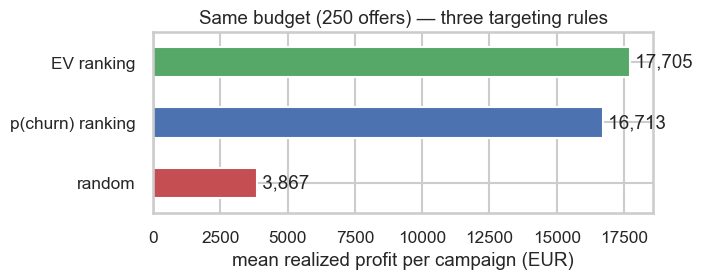

In [9]:
ordered = results.sort_values()
colors = {"EV ranking": GREEN, "p(churn) ranking": BLUE, "random": RED}

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ordered.plot.barh(ax=ax, color=[colors[k] for k in ordered.index])
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("mean realized profit per campaign (EUR)")
ax.set_title(f"Same budget ({BUDGET_N} offers) — three targeting rules")
for i, v in enumerate(ordered.values):
    ax.text(v, i, f" {v:,.0f}", va="center", ha="left" if v >= 0 else "right")
plt.tight_layout(); plt.show()

# 🕵️ Case B — Fraud & anomaly detection

> Canonical depth: [`05_industry_applications/18_fraud_anomaly_detection.ipynb`](../05_industry_applications/18_fraud_anomaly_detection.ipynb)

Case A had a comfortable positive rate (~13% churn). Fraud is the opposite world: **the positives are vanishingly rare** — here about 0.5% of payments — which breaks the intuitions *and* the metrics you built on balanced data. Same three beats though: a **model** (a risk score), the **money** (an analyst's time vs the loss from a missed fraud), and the **decision** (how many alerts to review).

## 7. The data — 90 days of payments

We draw transaction features, then plant three classic fraud patterns — late-night high-value theft, account takeover on a new device, and physically impossible travel speed — and OR them into a single rare label.

In [10]:
fraud_rng = np.random.default_rng(7)
n_tx = 30_000

day        = fraud_rng.integers(0, 90, n_tx)                       # day 0..89
hour       = fraud_rng.integers(0, 24, n_tx)
amount     = np.round(fraud_rng.lognormal(mean=3.4, sigma=0.9, size=n_tx), 2)  # median ~30 EUR
new_device = fraud_rng.binomial(1, 0.06, n_tx)
geo_kmh    = np.abs(fraud_rng.normal(8, 25, n_tx))                 # implied travel speed
mcc_risk   = fraud_rng.choice([0.2, 0.5, 0.9], n_tx, p=[0.7, 0.25, 0.05])  # merchant-category risk

# Plant three canonical fraud patterns, then OR them into one rare label.
night_theft = (hour <= 4) & (amount > 80)  & (fraud_rng.random(n_tx) < 0.18)
takeover    = (new_device == 1) & (amount > 150) & (fraud_rng.random(n_tx) < 0.30)
impossible  = (geo_kmh > 80) & (fraud_rng.random(n_tx) < 0.25)
is_fraud = np.zeros(n_tx, dtype=int)
is_fraud[night_theft | takeover | impossible] = 1

tx = pd.DataFrame({"day": day, "hour": hour, "amount": amount, "new_device": new_device,
                   "geo_kmh": geo_kmh.round(1), "mcc_risk": mcc_risk, "fraud": is_fraud})
print(tx.head())
print(f"\nFraud rate: {tx['fraud'].mean():.2%}   ({tx['fraud'].sum()} fraudulent of {n_tx:,})")

   day  hour  amount  new_device  geo_kmh  mcc_risk  fraud
0   85     3    8.05           0     28.2       0.2      0
1   56     7  133.39           0      4.8       0.5      0
2   61     4   12.82           0     21.4       0.5      0
3   80     2   66.03           0      9.7       0.2      0
4   52    17   32.87           0      1.2       0.5      0

Fraud rate: 0.56%   (168 fraudulent of 30,000)


## 8. ⚠️ The accuracy trap — see it once, never fall for it again

At ~0.5% fraud, a model that predicts **"honest"** for *every single transaction* is right ~99.5% of the time. It is also completely useless — it catches zero fraud. On imbalanced data, accuracy is not just imperfect; it is actively misleading.

> 🔬 **What's actually happening.** Accuracy is `(correct predictions) / (total)`. When 99.5% of rows share one label, a model can hit that label *by default* and score ~0.995 without learning a single thing about the 0.5% you actually care about — the metric is dominated by the majority class, and the rare class (the whole point) is a rounding error inside it. That is why we switch to **precision** and **recall**, which only ever talk about the positive class.

In [11]:
always_honest = np.zeros(len(tx), dtype=int)          # predict 'not fraud' for everyone
acc = accuracy_score(tx["fraud"], always_honest)
print(f"Accuracy of a model that does literally nothing: {acc:.2%}")
print(f"Fraud it actually catches:                        {int((always_honest & tx['fraud']).sum())}  🚩")
print("\nAccuracy rewards the majority class. On rare events it is a vanity metric — we need")
print("precision (are our alerts real?) and recall (what share of all fraud did we catch?).")

Accuracy of a model that does literally nothing: 99.44%
Fraud it actually catches:                        0  🚩

Accuracy rewards the majority class. On rare events it is a vanity metric — we need
precision (are our alerts real?) and recall (what share of all fraud did we catch?).


## 9. Model — a risk score, two ways

The honest metric for rare events is **PR-AUC** (area under the precision–recall curve; the baseline is the fraud rate itself). We build two scorers:

- a **cost-weighted supervised classifier** — when you have labelled fraud history, tell it that a missed fraud hurts far more than a false alarm via `class_weight`;
- an **Isolation Forest** — fully unsupervised; it never sees the label and just flags the *statistically weird*. Useful on day one when you have no labels yet — but remember **weird ≠ fraud**.

We split **by time** (train on days < 60, test on days ≥ 60): fraud patterns drift, so a random split would let the model peek at the future.

In [12]:
FEATS = ["hour", "amount", "new_device", "geo_kmh", "mcc_risk"]
train, ftest = tx[tx["day"] < 60].copy(), tx[tx["day"] >= 60].copy()

# Supervised, cost-weighted: a missed fraud is treated as ~30x worse than a false alarm.
clf = HistGradientBoostingClassifier(max_iter=250, class_weight={0: 1, 1: 30},
                                     random_state=RANDOM_STATE)
clf.fit(train[FEATS], train["fraud"])
score_sup = clf.predict_proba(ftest[FEATS])[:, 1]

# Unsupervised: Isolation Forest never sees the 'fraud' column.
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=RANDOM_STATE)
iso.fit(train[FEATS])
score_iso = -iso.score_samples(ftest[FEATS])          # higher = more anomalous

print(f"Test transactions: {len(ftest):,}  |  fraud among them: {ftest['fraud'].sum()}")
print(f"PR-AUC  supervised (cost-weighted):   {average_precision_score(ftest['fraud'], score_sup):.3f}")
print(f"PR-AUC  isolation forest (no labels): {average_precision_score(ftest['fraud'], score_iso):.3f}")
print(f"random-guess baseline (= fraud rate): {ftest['fraud'].mean():.3f}")

Test transactions: 10,140  |  fraud among them: 60
PR-AUC  supervised (cost-weighted):   0.176
PR-AUC  isolation forest (no labels): 0.043
random-guess baseline (= fraud rate): 0.006


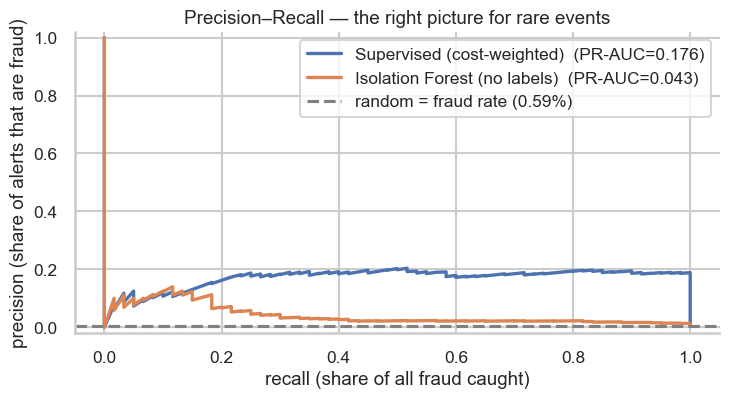

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, sc, color in [("Supervised (cost-weighted)", score_sup, BLUE),
                        ("Isolation Forest (no labels)", score_iso, ORANGE)]:
    prec, rec, _ = precision_recall_curve(ftest["fraud"], sc)
    ap = average_precision_score(ftest["fraud"], sc)
    ax.plot(rec, prec, lw=2.4, color=color, label=f"{name}  (PR-AUC={ap:.3f})")
ax.axhline(ftest["fraud"].mean(), ls="--", color="grey",
           label=f"random = fraud rate ({ftest['fraud'].mean():.2%})")
ax.set(xlabel="recall (share of all fraud caught)",
       ylabel="precision (share of alerts that are fraud)",
       title="Precision–Recall — the right picture for rare events", ylim=(-0.02, 1.02))
ax.legend(loc="upper right"); sns.despine(); plt.tight_layout(); plt.show()

## 10. Money → decision — the review queue

A fraud team can only review so many alerts a day. That capacity — not a probability threshold — is the real decision variable. Rank transactions by risk score and review the **top k**; the metrics that matter are **precision@k** (what share of the k alerts are real fraud) and **recall@k** (what share of *all* fraud those k alerts catch).

Then attach money: each review costs an analyst's time; each fraud caught prevents a loss. The queue's value is **euros prevented − review cost**.

In [14]:
def queue_metrics(y_true, scores, k):
    """Review the top-k riskiest transactions; return precision@k, recall@k, count caught."""
    idx = np.argsort(-scores)[:k]
    caught = int(y_true.iloc[idx].sum())
    return {"k": k, "precision@k": caught / k,
            "recall@k": caught / int(y_true.sum()), "caught": caught}

K = 50 * 30                                           # analysts review 50/day for 30 test days
queue = pd.DataFrame([
    dict(model="supervised",       **queue_metrics(ftest["fraud"], score_sup, K)),
    dict(model="isolation forest", **queue_metrics(ftest["fraud"], score_iso, K)),
]).set_index("model")
print(queue.round(3), "\n")

REVIEW_COST, AVG_FRAUD_LOSS = 4.0, 220.0              # EUR per review / per undetected fraud
for mdl in queue.index:
    prevented = queue.loc[mdl, "caught"] * AVG_FRAUD_LOSS - K * REVIEW_COST
    print(f"{mdl:>17}: net € prevented over 30 days ≈ {prevented:>10,.0f} EUR "
          f"(caught {int(queue.loc[mdl, 'caught'])} frauds)")

                     k  precision@k  recall@k  caught
model                                                
supervised        1500        0.040     1.000      60
isolation forest  1500        0.023     0.567      34 

       supervised: net € prevented over 30 days ≈      7,200 EUR (caught 60 frauds)
 isolation forest: net € prevented over 30 days ≈      1,480 EUR (caught 34 frauds)


---

### ✋ Quick exercise (~2 min) — Precision@k for a leaner team

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Budget is cut: analysts can now review only **`k = 600`** transactions total (down from 1,500). For the **supervised** score (`score_sup`), take the 600 riskiest test transactions and compute **precision@k** — the share of those 600 that are truly fraud. Reuse the `np.argsort(-scores)[:k]` trick. Does precision go **up or down** as the queue shrinks?

In [15]:
# ✍️ Your turn 👇
k = 600
top_k_idx = np.argsort(-score_sup)[:k]     # the k riskiest test transactions
precision_at_k = ...                        # share of those k that are truly fraud

<details>
<summary>✅ <b>Solution</b></summary>

```python
k = 600
top_k_idx = np.argsort(-score_sup)[:k]
precision_at_k = ftest["fraud"].iloc[top_k_idx].mean()
print(f"precision@{k} = {precision_at_k:.2%}  (vs the {ftest['fraud'].mean():.2%} base rate)")
```

`ftest["fraud"].iloc[top_k_idx].mean()` is the share of flagged rows that are fraud. Shrinking the queue **raises** precision — you keep only the most confident alerts, so a higher fraction are real fraud — but it **lowers** recall, because fewer frauds are reviewed in total. That trade-off is exactly what *"how big should the queue be?"* is really asking.
</details>

## 11. Case C — Customer segmentation (RFM + k-means)

Cases A and B *predicted a label*. Segmentation is **unsupervised** — no target at all. We compress customers into a few **personas a human can act on**, using the 40-year-old **RFM** features (Recency, Frequency, Monetary) plus **k-means**. The *model → money → decision* beat still holds: each segment is a **different campaign**, and the reachable value of a segment decides where the budget goes.

> ⚠️ **The one trap: scale first.** Monetary runs 0–5000 €, recency 0–365 days. Unscaled, k-means just sorts by whichever feature has the biggest numbers (revenue). `StandardScaler` puts them on equal footing.

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Three latent behaviours planted in the data; k-means must recover them blind (no labels used).
rng = np.random.default_rng(RANDOM_STATE)
n = 600
kind = rng.choice(["loyal", "at_risk", "newcomer"], size=n, p=[0.35, 0.30, 0.35])
recency   = np.where(kind == "loyal",   rng.integers(1, 30, n),
            np.where(kind == "at_risk", rng.integers(90, 365, n), rng.integers(1, 60, n)))
frequency = np.where(kind == "loyal",   rng.integers(8, 25, n),
            np.where(kind == "at_risk", rng.integers(3, 10, n), rng.integers(1, 4, n)))
monetary  = np.where(kind == "loyal",   rng.normal(3000, 600, n),
            np.where(kind == "at_risk", rng.normal(2200, 500, n), rng.normal(400, 150, n))).clip(50)
rfm = pd.DataFrame({"recency_days": recency, "frequency": frequency, "monetary_eur": monetary.round(0)})

# ⚠️ scale BEFORE k-means, or it silently degenerates into "sort by monetary"
X_rfm = StandardScaler().fit_transform(rfm)
rfm["segment"] = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_rfm)

# Profile each cluster — the mean customer is what you *name*
profile = (rfm.groupby("segment")
              .agg(customers=("monetary_eur", "size"),
                   recency=("recency_days", "mean"),
                   frequency=("frequency", "mean"),
                   monetary=("monetary_eur", "mean"))
              .round(0).astype(int))
profile

,customers,recency,frequency,monetary
segment,,,,
0,175,232,6,2241
1,97,15,21,2933
2,208,30,2,408
3,120,18,12,3031


Read the profile and **name** each segment — the step that turns a cluster id into a decision. A cluster with low recency + high frequency + high spend is your **champions** (protect them); high recency + still-decent spend is **at-risk big spenders** (the highest *reachable* value — win them back); low-everything is **bargain newcomers** (nurture cheaply). A picture makes the split obvious:

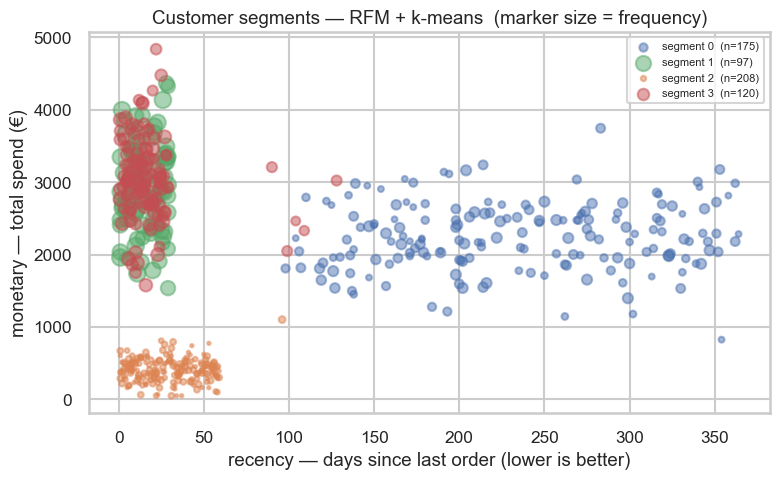

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
palette = [BLUE, GREEN, ORANGE, RED]
for seg, grp in rfm.groupby("segment"):
    ax.scatter(grp["recency_days"], grp["monetary_eur"], s=grp["frequency"] * 6,
               alpha=0.5, color=palette[seg % 4], label=f"segment {seg}  (n={len(grp)})")
ax.set_xlabel("recency — days since last order (lower is better)")
ax.set_ylabel("monetary — total spend (€)")
ax.set_title("Customer segments — RFM + k-means  (marker size = frequency)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

Same spine as Cases A and B: the segment is a **decision** — who gets which campaign — not just a cluster id. Marketing spends its budget where the *reachable value* is highest (usually the at-risk big spenders), not where raw spend is highest.

→ Full depth — recommenders, hit-rate@k, cold-start — in the canonical [`19_segmentation_recommenders.ipynb`](../05_industry_applications/19_segmentation_recommenders.ipynb).

## 12. The last row — operations

One more member of the module rides the *same* model → money → decision spine — only the model in the first slot changes.

### ⚙️ Demand forecasting & predictive maintenance — [`20_demand_maintenance.ipynb`](../05_industry_applications/20_demand_maintenance.ipynb)
The operations double feature. **Demand forecasting** turns a per-SKU forecast into a stock order: forecast error becomes **safety stock** for a target service level, and the **newsvendor** rule balances the cost of a stockout against the cost of holding inventory. **Predictive maintenance** turns sensor telemetry into a "fails within 7 days" classifier, then picks the alert threshold from the cost of downtime vs a false alarm. In operations the forecast itself is worthless — only the decision it feeds (how much to order, when to service the machine) has value.

## 🧪 Practice exercises

Five exercises, warm-up to a bug-hunt. Try each before opening the solution.

### Exercise 1 — ⭐ Expected value of a single offer

Write `ev_of_offer(p_churn, clv, save_rate=0.30, offer_cost=60.0)` returning the expected profit `p_churn × save_rate × clv − offer_cost` of sending one retention offer. Test it on a customer with `p_churn=0.4`, `clv=1200`. Is it worth sending?

In [18]:
# Your code here 👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
def ev_of_offer(p_churn, clv, save_rate=0.30, offer_cost=60.0):
    return p_churn * save_rate * clv - offer_cost

ev = ev_of_offer(0.4, 1200)
print(f"EV = {ev:,.2f} EUR  ->  {'send ✅' if ev > 0 else 'skip'}")
```

`0.4 × 0.30 × 1200 − 60 = 144 − 60 = €84 > 0`, so the offer is worth sending. Flip it around: this customer's break-even churn probability is `60 / (0.30 × 1200) = 0.167`, and `0.4` clears it comfortably.
</details>

### Exercise 2 — ⭐⭐ A `precision_recall_at_k` helper

Write `precision_recall_at_k(y_true, scores, k)` that reviews the top-`k` by `scores` and returns `(precision, recall)` as a tuple. Run it on the supervised fraud score for `k = 300` and `k = 1500`, and confirm precision falls as `k` grows.

In [19]:
# Your code here 👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
def precision_recall_at_k(y_true, scores, k):
    idx = np.argsort(-scores)[:k]
    y = np.asarray(y_true)
    caught = int(y[idx].sum())
    return caught / k, caught / int(y.sum())

for k in (300, 1500):
    prec, rec = precision_recall_at_k(ftest["fraud"].to_numpy(), score_sup, k)
    print(f"k={k:>4}:  precision={prec:.2%}  recall={rec:.2%}")
```

Precision is highest at small `k` (only the most confident alerts) and decays as the queue grows to include weaker ones; recall moves the opposite way. Picking `k` *is* picking your point on that trade-off — set by how many analysts you can staff, not by a magic `0.5`.
</details>

### Exercise 3 — ⭐⭐ Where do the two detectors disagree?

The supervised model and the Isolation Forest rank transactions differently. Take each model's **top 300** test transactions (by score) as sets of positional indices and report how many they share (the intersection size) versus how many are unique to each. What does a large disagreement suggest about *combining* them?

In [20]:
# Your code here 👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
top_sup = set(np.argsort(-score_sup)[:300])
top_iso = set(np.argsort(-score_iso)[:300])
shared = top_sup & top_iso
print(f"shared: {len(shared)}  |  supervised-only: {len(top_sup - top_iso)}  "
      f"|  isolation-only: {len(top_iso - top_sup)}")
print(f"agreement: {len(shared) / 300:.0%} of the top-300 alerts overlap")
```

The overlap is modest — the two detectors are largely looking at *different* transactions. That is exactly why an ensemble can help: the supervised model catches known fraud patterns it was trained on, while the Isolation Forest can surface *novel* weirdness no label ever taught it. Low agreement between complementary models is an opportunity, not a contradiction (see Stretch D).
</details>

### Exercise 4 — ⭐⭐ The cost matrix sets the class weight

Right now a missed fraud is priced at `AVG_FRAUD_LOSS = 220` and a review at `REVIEW_COST = 4`. Retrain the supervised classifier with `class_weight={0: 1, 1: w}` for `w` in `[1, 10, 30, 100]`, and for each print PR-AUC and precision@1500. Which weight best matches the ~55:1 cost ratio between a missed fraud and a wasted review?

In [21]:
# Your code here 👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
for w in [1, 10, 30, 100]:
    clf_w = HistGradientBoostingClassifier(max_iter=250, class_weight={0: 1, 1: w},
                                           random_state=RANDOM_STATE).fit(train[FEATS], train["fraud"])
    s = clf_w.predict_proba(ftest[FEATS])[:, 1]
    idx = np.argsort(-s)[:1500]
    print(f"w={w:>3}:  PR-AUC={average_precision_score(ftest['fraud'], s):.3f}  "
          f"precision@1500={ftest['fraud'].iloc[idx].mean():.2%}")
```

The class weight is where the cost matrix enters the *model* (rather than the decision rule): a weight near the cost ratio (≈55) tells the classifier to treat one missed fraud as ~55 wasted reviews. Notice how little the numbers actually move here, though — PR-AUC barely changes and precision@1500 is flat. That is the real lesson: reweighting mostly *rescales* the predicted probabilities rather than *reordering* them, so a ranking-based decision (review the top-`k`) is largely insensitive to the weight. Class weight bites hardest when you threshold on the probability directly (`p > 0.5`); when you instead rank and cut at a staffing capacity `k`, the ordering is what counts. Tune the weight for a probability threshold; tune `k` for a queue.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

A stakeholder asks *"what's the **accuracy** of our fraud AI?"* and an analyst writes the cell below to answer it. It **crashes** — and even the *question* is a trap. Explain both the runtime error and the deeper conceptual bug, then write the honest evaluation.

In [22]:
# 🐞 Buggy: "measure the accuracy of our fraud model"
acc = accuracy_score(ftest["fraud"], score_sup)     # score_sup holds probabilities, not labels
print(f"Fraud AI accuracy: {acc:.2%}")

ValueError: Classification metrics can't handle a mix of binary and continuous targets

<details>
<summary>💡 <b>Solution</b></summary>

Two bugs, one mechanical and one conceptual.

**The crash.** `score_sup` holds *probabilities* (floats like `0.03`), but `accuracy_score` expects *labels* (`0`/`1`). Mixing continuous scores with a binary target raises `ValueError: Classification metrics can't handle a mix of binary and continuous targets`. You would have to threshold first (e.g. `score_sup > 0.5`).

**The deeper trap.** Even once it runs, **accuracy is the wrong metric** on a 0.5%-imbalanced problem — predicting "honest" for everyone already scores ~99.5% while catching zero fraud (§8). Report a rare-event metric instead:

```python
print(f"PR-AUC: {average_precision_score(ftest['fraud'], score_sup):.3f}")
idx = np.argsort(-score_sup)[:1500]
print(f"precision@1500: {ftest['fraud'].iloc[idx].mean():.2%}  |  "
      f"recall@1500: {ftest['fraud'].iloc[idx].sum() / ftest['fraud'].sum():.2%}")
```

The fix changes *what you measure*, not just how you call it — PR-AUC and precision/recall@k tell you whether the queue is worth an analyst's time; accuracy never could.
</details>

## 🧠 Stretch exercises

Two harder, open-ended problems (C and D — the fast track keeps the two upper-tier stretches). Each solution ends with the *why*.

### Stretch exercise C — ⭐⭐⭐ How many offers should the campaign send?

The budget in §6 *fixed* the number of offers at 250. But is 250 **optimal**? Rank the test customers by `ev_offer` (descending), take the **cumulative** expected profit as you send more offers, and find the number of offers `k*` that **maximises** cumulative EV. Plot the curve and mark `k*`. Interpret what the customer at position `k*` looks like.

In [23]:
# Starter: sort test by ev_offer (desc), cumulatively sum ev_offer, then argmax the curve.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
order = test.sort_values("ev_offer", ascending=False)
cum_ev = order["ev_offer"].cumsum().to_numpy()
k_star = int(np.argmax(cum_ev)) + 1

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(range(1, len(cum_ev) + 1), cum_ev, lw=2, color=GREEN)
ax.axvline(k_star, ls="--", color=ORANGE)
ax.set(xlabel="offers sent (ranked by EV)", ylabel="cumulative expected profit (EUR)",
       title=f"Optimum ≈ {k_star} offers  (EV ≈ {cum_ev[k_star-1]:,.0f} EUR)")
plt.tight_layout(); plt.show()
print(f"k* = {k_star} offers; the marginal customer #{k_star} has ev_offer ≈ 0.")
```

**Reasoning.** The cumulative-EV curve rises while each additional customer still has `ev_offer > 0`, peaks exactly where `ev_offer` crosses zero, and then *declines* as you start paying €60 to reach customers whose expected save is worth less than the offer. So the optimal campaign size is not a budget you guessed — it is **the count of customers with positive expected value**, and the customer at `k*` is the break-even one (`p_i ≈ p_i*`). If your budget buys fewer than `k*` offers you are leaving profit on the table; if it buys more, the extra offers destroy value. The budget and the model should *meet* at `k*`, not be set independently.
</details>

### Stretch exercise D — ⭐⭐⭐ Rank-ensemble the two fraud detectors

Exercise 3 showed the supervised model and the Isolation Forest flag largely *different* transactions. Combine them: convert each score to a **percentile rank** (`pd.Series.rank(pct=True)`), average the two ranks into an ensemble score, and compare **precision@1500** of the ensemble against each detector alone. Does averaging ranks beat the better single model?

In [24]:
# Starter: convert each score to a percentile rank, average them, then precision@1500.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def precision_at_k(y_true, scores, k=1500):
    idx = np.argsort(-scores)[:k]
    return np.asarray(y_true)[idx].mean()

r_sup = pd.Series(score_sup).rank(pct=True).to_numpy()
r_iso = pd.Series(score_iso).rank(pct=True).to_numpy()
ensemble = (r_sup + r_iso) / 2
yt = ftest["fraud"].to_numpy()

for name, sc in [("supervised", score_sup), ("isolation forest", score_iso),
                 ("rank ensemble", ensemble)]:
    print(f"{name:>17}: precision@1500 = {precision_at_k(yt, sc):.2%}")
```

**Reasoning.** Averaging **ranks** rather than raw scores side-steps the fact that the two scores live on totally different scales (a calibrated-ish probability vs an unbounded anomaly score) — ranks put both on a common `0..1` footing before combining. Does it *win*? Here, no: the ensemble **ties** the supervised model (both already catch every fraud within 1,500 alerts, so precision is identical), while the Isolation Forest alone is much weaker. That is the honest and common outcome — averaging a strong detector with a much weaker one rarely beats the strong one. Ensembling pays off when the models are **comparably strong and make independent errors**; Exercise 3 showed the errors here *are* independent (only ~12% overlap), but the strengths are mismatched, so the blend just tracks the stronger model. Rank-averaging is still the right *mechanism* when you cannot trust scores to be comparable — in production you would learn the blend weight on a validation slice and test at the `k` you actually staff, rather than fixing 50/50 at k=1500.
</details>

## 🧠 Key takeaways

1. **Model → money → decision.** Every application in this module is the same spine: a probability or forecast, a cost structure, and a rule that turns the number into an action. The model is a *third* of the job; the costs and the decision are the rest.
2. **A probability is not a decision.** `.predict()`'s silent `0.5` cutoff is almost never the business-optimal one. Derive the operating point from costs.
3. **CLV makes risk actionable.** An identical churn probability deserves different attention at different customer value; the **expected-value threshold** `p* = offer_cost / (save_rate × CLV)` is *per customer*, and value-aware targeting beats risk-only targeting at the same budget.
4. **Accuracy is a vanity metric on imbalanced data.** At 0.5% fraud, "predict honest for everyone" scores 99.5% and catches nothing. Use **PR-AUC**, **precision@k**, and **recall@k**.
5. **Capacity, not a threshold, sizes a review queue.** Rank by risk, review the top-k your analysts can handle, and value the queue in **euros prevented − review cost**.
6. **Leakage and time discipline decide whether the number is real.** Post-outcome columns (refunds, cancellation reasons) inflate churn AUC; random splits let fraud models peek at the future. Ask *"would this value exist at scoring time?"* and split by time when patterns drift.
7. **The same frame scales.** Segmentation (reachable value per persona) and operations (safety stock, newsvendor, maintenance thresholds) are the identical model → money → decision loop with a different model in the first slot.

## ✅ Self-assessment

- [ ] Explain the model → money → decision pattern in one sentence per beat
- [ ] Compute a subscription CLV with the capped `m / c` formula
- [ ] Derive the per-customer break-even offer threshold `p* = offer_cost / (save_rate × CLV)`
- [ ] Say why a global `0.5` cutoff is wrong for every customer at once
- [ ] Simulate a budget-constrained campaign and compare targeting strategies by realized profit
- [ ] Explain why accuracy is misleading at 0.5% prevalence
- [ ] Compute precision@k and recall@k for a capacity-sized review queue
- [ ] Convert model alerts into expected euros prevented
- [ ] Spot post-outcome leakage in a churn model and a leaky random split in a fraud model
- [ ] Place segmentation and demand/maintenance in the same decision frame

## 🚀 Next step

Continue with **Notebook 18 (fast track) — Document AI & Observability**, where a model's output stops being a number and becomes *structured information pulled from messy documents* — and where you learn to watch a deployed AI system in production.

Want the full depth on everything above — uplift models and the retention playbook, drift-aware fraud queues, RFM + k-means segmentation, and the newsvendor rule for stock? Open the canonical module: [`05_industry_applications/`](../05_industry_applications/) (NB 17 churn/CLV · NB 18 fraud · NB 19 segmentation · NB 20 demand/maintenance).